## Act 4: The City as a Signal

At large scale, individual trips become less important and the system
reveals patterns over time.

Objective:
- Aggregate trip data across time (hour/day)
- Identify patterns in trip volume, fare, and tipping behavior
- Distinguish between real patterns and noise
- Determine if the system is stable, cyclical, or irregular

In [1]:
import pandas as pd

files = [
    "yellow_tripdata_2023-02.parquet",
    "yellow_tripdata_2023-03.parquet",
    "yellow_tripdata_2023-04.parquet",
    "yellow_tripdata_2023-05.parquet",
    "yellow_tripdata_2023-06.parquet"
]

cols = [
    "tpep_pickup_datetime",
    "trip_distance",
    "fare_amount",
    "tip_amount"
]

df = pd.concat([
    pd.read_parquet(f, columns=cols).sample(frac=0.2)
    for f in files
], ignore_index=True)

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

In [2]:
#feature engineering 
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day'] = df['tpep_pickup_datetime'].dt.day
df['weekday'] = df['tpep_pickup_datetime'].dt.day_name()
df['month'] = df['tpep_pickup_datetime'].dt.month

df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100

In [3]:
#hourly patter - city rhythm 
hourly = df.groupby('hour').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean',
    'tip_percentage': 'mean'
}).rename(columns={'trip_distance': 'trip_count'})

In [4]:
#daily pattern 
daily = df.groupby('weekday').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean',
    'tip_percentage': 'mean'
}).rename(columns={'trip_distance': 'trip_count'})

In [5]:
#monthly pattern 
monthly = df.groupby('month').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean',
    'tip_percentage': 'mean'
}).rename(columns={'trip_distance': 'trip_count'})

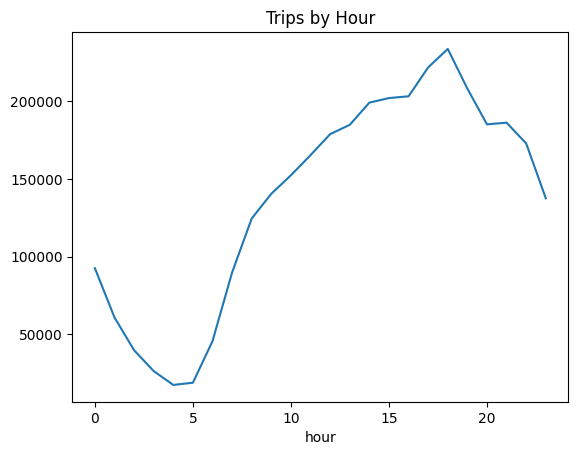

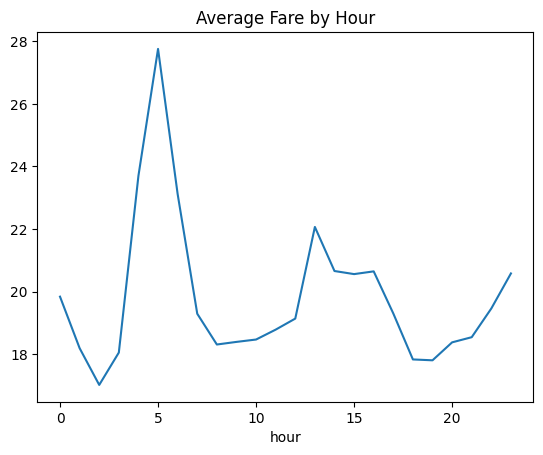

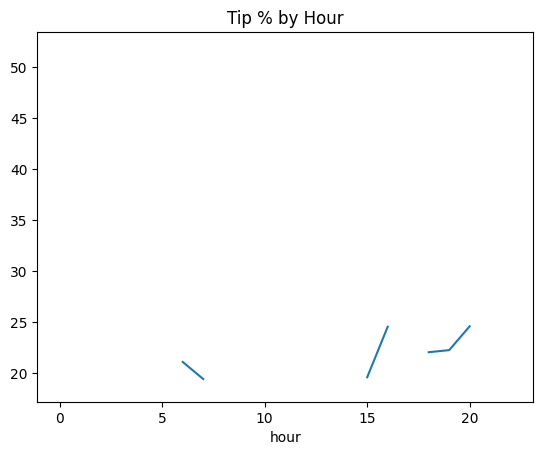

In [ ]:
#Visualize Patterns
import matplotlib.pyplot as plt

# Hourly trips
hourly['trip_count'].plot(title="Trips by Hour")
plt.show()

# Fare trend
hourly['fare_amount'].plot(title="Average Fare by Hour")
plt.show()

# Tip behavior
hourly['tip_percentage'].plot(title="Tip % by Hour")
plt.show()

## Observations

- Trip volume peaks during morning and evening hours
- Lower activity during late night
- Tip percentage varies slightly but follows similar pattern

## which patterns persist?
- Peak hours (morning/evening rush)
- Consistent daily demand cycles

## which patterns disappear?
- Minor fluctuations in tip %
- Small spikes in fare

## which patterns were never real? 
- Minor fluctuations in tip %
- Small spikes in fare

## graph interpretation 
1. HOURLY TRIP COUNT (City Rhythm)

-Low trips at night (2–5 AM)
-Increase in morning
-Peak in evening

2. AVERAGE FARE BY HOUR

-Slight variation across hours
-Maybe higher during peak times

3. TIP PERCENTAGE BY HOUR

-Small fluctuations
-No dramatic spikes

## Final Conclusion

At scale, the NYC taxi system demonstrates clear cyclical patterns driven by human activity,
particularly daily routines and commuting behavior.

While some fluctuations appear in the data, many of these do not persist across time and are likely artifacts of observation or noise.

Thus, the system is best characterized as a stable but dynamic system with strong cyclical structure rather than randomness.